# Traffic Risk Assessment EDA

This notebook analyzes the full US Accidents dataset in three views:

- **before_2020_raw**: raw records from `data/raw/US.csv` with `Start_Time` year before 2020.
- **from_2020_raw**: raw records from `data/raw/US.csv` with `Start_Time` year from 2020 onward.
- **before_2020_featured**: before-2020 records after the production feature-engineering contract in `data/process/us_train_offline_before_2020.csv`.

The raw views are normalized into the same EDA column names so charts can compare periods without assuming raw files already contain `event_year`.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make this notebook runnable from Jupyter, VS Code, or the repository root.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "processing").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from processing.feature_engineering import encode_road_type, encode_weather_condition

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

print(f"Project root: {PROJECT_ROOT}")


Project root: /home/hung/YEAR 3/Big Data/BTL


In [2]:
RAW_FULL_PATH = PROJECT_ROOT / "data/raw/US.csv"
BEFORE_RAW_SPLIT_PATH = PROJECT_ROOT / "data/split/us_train_offline_before_2020.csv"
AFTER_RAW_SPLIT_PATH = PROJECT_ROOT / "data/split/us_pipeline_from_2020.csv"
BEFORE_FEATURE_PATH = PROJECT_ROOT / "data/process/us_train_offline_before_2020.csv"

SPLIT_YEAR = 2020
CHUNK_SIZE = 20_000
RANDOM_SEED = 42

PERIOD_ORDER = ["before_2020_raw", "from_2020_raw", "before_2020_featured"]
PERIOD_PALETTE = {
    "before_2020_raw": "#4C78A8",
    "from_2020_raw": "#F58518",
    "before_2020_featured": "#54A24B",
}

print("raw full file:", RAW_FULL_PATH, RAW_FULL_PATH.exists())
print("before_2020 raw split fallback:", BEFORE_RAW_SPLIT_PATH, BEFORE_RAW_SPLIT_PATH.exists())
print("from_2020 raw split fallback:", AFTER_RAW_SPLIT_PATH, AFTER_RAW_SPLIT_PATH.exists())
print("before_2020 feature file:", BEFORE_FEATURE_PATH, BEFORE_FEATURE_PATH.exists())


raw full file: /home/hung/YEAR 3/Big Data/BTL/data/raw/US.csv True
before_2020 raw split fallback: /home/hung/YEAR 3/Big Data/BTL/data/split/us_train_offline_before_2020.csv True
from_2020 raw split fallback: /home/hung/YEAR 3/Big Data/BTL/data/split/us_pipeline_from_2020.csv True
before_2020 feature file: /home/hung/YEAR 3/Big Data/BTL/data/process/us_train_offline_before_2020.csv True


In [3]:
ENGINEERED_COLUMNS = [
    "event_id", "event_year", "event_time", "true_severity", "lat", "lon",
    "hour", "day_of_week", "is_weekend", "is_rush_hour", "weather_code",
    "temperature_f", "humidity", "wind_speed_mph", "visibility_mi",
    "road_type_code", "is_junction", "has_traffic_signal", "is_crossing",
    "is_roundabout", "is_stop", "is_station", "is_railway", "is_night",
]

RAW_USECOLS = [
    "ID", "Severity", "Start_Time", "Start_Lat", "Start_Lng", "Street",
    "Weather_Condition", "Temperature(F)", "Humidity(%)", "Wind_Speed(mph)",
    "Visibility(mi)", "Junction", "Traffic_Signal", "Crossing", "Roundabout",
    "Stop", "Station", "Railway", "Sunrise_Sunset",
]


def _require_file(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")


def _bool_to_int(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.lower().isin({"true", "1", "yes", "y"}).astype("int8")


def _numeric(series: pd.Series, default: float, lower: float | None = None, upper: float | None = None) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").fillna(default).astype("float32")
    if lower is not None or upper is not None:
        values = values.clip(lower=lower, upper=upper)
    return values


def _spark_day_of_week(datetimes: pd.Series) -> pd.Series:
    return (datetimes.dt.isocalendar().day % 7 + 1).astype("int8")


def _is_rush_hour(hours: pd.Series) -> pd.Series:
    return (hours.between(7, 9) | hours.between(16, 18)).astype("int8")


def raw_chunk_to_eda_schema(chunk: pd.DataFrame) -> pd.DataFrame:
    """Normalize one raw US Accidents chunk into the EDA schema without requiring event_year in the raw CSV."""
    event_time = pd.to_datetime(chunk["Start_Time"], errors="coerce")
    severity = pd.to_numeric(chunk["Severity"], errors="coerce")
    lat = pd.to_numeric(chunk["Start_Lat"], errors="coerce")
    lon = pd.to_numeric(chunk["Start_Lng"], errors="coerce")
    event_id = chunk["ID"].astype("string").str.strip()

    valid = (
        event_time.notna()
        & severity.isin([1, 2, 3, 4])
        & lat.between(-90, 90)
        & lon.between(-180, 180)
        & event_id.notna()
        & (event_id != "")
    )

    chunk = chunk.loc[valid].copy()
    event_time = event_time.loc[valid]
    severity = severity.loc[valid]
    lat = lat.loc[valid]
    lon = lon.loc[valid]
    hours = event_time.dt.hour.astype("int8")

    out = pd.DataFrame(index=chunk.index)
    out["event_id"] = event_id.loc[valid].astype("string")
    out["event_year"] = event_time.dt.year.astype("int16")
    out["event_time"] = event_time.dt.strftime("%Y-%m-%dT%H:%M:%S")
    out["true_severity"] = severity.astype("int8")
    out["lat"] = lat.astype("float32")
    out["lon"] = lon.astype("float32")
    out["hour"] = hours
    out["day_of_week"] = _spark_day_of_week(event_time)
    out["is_weekend"] = out["day_of_week"].isin([1, 7]).astype("int8")
    out["is_rush_hour"] = _is_rush_hour(hours)
    out["weather_code"] = chunk["Weather_Condition"].map(encode_weather_condition).astype("int8")
    out["temperature_f"] = _numeric(chunk["Temperature(F)"], default=50.0, lower=-40.0, upper=130.0)
    out["humidity"] = _numeric(chunk["Humidity(%)"], default=50.0, lower=0.0, upper=100.0)
    out["wind_speed_mph"] = _numeric(chunk["Wind_Speed(mph)"], default=0.0, lower=0.0, upper=100.0)
    out["visibility_mi"] = _numeric(chunk["Visibility(mi)"], default=10.0, lower=0.0, upper=10.0)
    out["road_type_code"] = chunk["Street"].map(encode_road_type).astype("int8")
    out["is_junction"] = _bool_to_int(chunk["Junction"])
    out["has_traffic_signal"] = _bool_to_int(chunk["Traffic_Signal"])
    out["is_crossing"] = _bool_to_int(chunk["Crossing"])
    out["is_roundabout"] = _bool_to_int(chunk["Roundabout"])
    out["is_stop"] = _bool_to_int(chunk["Stop"])
    out["is_station"] = _bool_to_int(chunk["Station"])
    out["is_railway"] = _bool_to_int(chunk["Railway"])
    out["is_night"] = chunk["Sunrise_Sunset"].fillna("").astype(str).str.strip().str.lower().eq("night").astype("int8")
    return out[ENGINEERED_COLUMNS]


def load_raw_periods_from_full(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Read the full raw CSV once and split it into before/after-2020 EDA frames."""
    _require_file(path)
    before_parts = []
    after_parts = []
    total_rows = 0
    valid_rows = 0

    for chunk in pd.read_csv(path, usecols=RAW_USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
        total_rows += len(chunk)
        normalized = raw_chunk_to_eda_schema(chunk)
        valid_rows += len(normalized)

        before_part = normalized.loc[normalized["event_year"] < SPLIT_YEAR].copy()
        after_part = normalized.loc[normalized["event_year"] >= SPLIT_YEAR].copy()

        if not before_part.empty:
            before_part["period"] = "before_2020_raw"
            before_part["source_schema"] = "raw_full"
            before_parts.append(before_part)
        if not after_part.empty:
            after_part["period"] = "from_2020_raw"
            after_part["source_schema"] = "raw_full"
            after_parts.append(after_part)

    before_df = pd.concat(before_parts, ignore_index=True) if before_parts else pd.DataFrame(columns=ENGINEERED_COLUMNS + ["period", "source_schema"])
    after_df = pd.concat(after_parts, ignore_index=True) if after_parts else pd.DataFrame(columns=ENGINEERED_COLUMNS + ["period", "source_schema"])
    scan_summary = pd.DataFrame([
        {"source": str(path.relative_to(PROJECT_ROOT)), "rows_read": total_rows, "valid_eda_rows": valid_rows, "invalid_or_dropped_rows": total_rows - valid_rows},
    ])
    return before_df, after_df, scan_summary


def load_raw_period_from_split(path: Path, period: str, year_filter: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Fallback when the full raw file is unavailable: read one pre-split raw CSV in chunks."""
    _require_file(path)
    parts = []
    total_rows = 0
    valid_rows = 0
    for chunk in pd.read_csv(path, usecols=RAW_USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
        total_rows += len(chunk)
        normalized = raw_chunk_to_eda_schema(chunk)
        if year_filter == "before":
            normalized = normalized.loc[normalized["event_year"] < SPLIT_YEAR]
        elif year_filter == "after":
            normalized = normalized.loc[normalized["event_year"] >= SPLIT_YEAR]
        valid_rows += len(normalized)
        if not normalized.empty:
            normalized = normalized.copy()
            normalized["period"] = period
            normalized["source_schema"] = "raw_split"
            parts.append(normalized)
    df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=ENGINEERED_COLUMNS + ["period", "source_schema"])
    summary = pd.DataFrame([
        {"source": str(path.relative_to(PROJECT_ROOT)), "rows_read": total_rows, "valid_eda_rows": valid_rows, "invalid_or_dropped_rows": total_rows - valid_rows},
    ])
    return df, summary


def load_before_2020_featured(path: Path) -> pd.DataFrame:
    _require_file(path)
    df = pd.read_csv(path, usecols=ENGINEERED_COLUMNS, low_memory=False)
    df["period"] = "before_2020_featured"
    df["source_schema"] = "engineered_feature_csv"
    return df


def period_subplots(n_periods: int | None = None, *, width: float = 5.5, height: float = 4.0, sharex: bool = False, sharey: bool = False):
    n = n_periods or len(PERIOD_ORDER)
    fig, axes = plt.subplots(1, n, figsize=(width * n, height), sharex=sharex, sharey=sharey)
    return fig, np.atleast_1d(axes)


if RAW_FULL_PATH.exists():
    before_raw_df, after_raw_df, raw_scan_summary = load_raw_periods_from_full(RAW_FULL_PATH)
else:
    before_raw_df, before_summary = load_raw_period_from_split(BEFORE_RAW_SPLIT_PATH, "before_2020_raw", "before")
    after_raw_df, after_summary = load_raw_period_from_split(AFTER_RAW_SPLIT_PATH, "from_2020_raw", "after")
    raw_scan_summary = pd.concat([before_summary, after_summary], ignore_index=True)

before_featured_df = load_before_2020_featured(BEFORE_FEATURE_PATH)
eda_df = pd.concat([before_raw_df, after_raw_df, before_featured_df], ignore_index=True)
eda_df["period"] = pd.Categorical(eda_df["period"], categories=PERIOD_ORDER, ordered=True)

print("before_raw_df shape:", before_raw_df.shape)
print("after_raw_df shape:", after_raw_df.shape)
print("before_featured_df shape:", before_featured_df.shape)
print("combined EDA shape:", eda_df.shape)
display(raw_scan_summary)
display(eda_df.head())


/tmp/ipykernel_16917/1061834362.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  event_time = pd.to_datetime(chunk["Start_Time"], errors="coerce")


before_raw_df shape: (2976413, 26)
after_raw_df shape: (3786927, 26)
before_featured_df shape: (2975837, 26)
combined EDA shape: (9739177, 26)


,source,rows_read,valid_eda_rows,invalid_or_dropped_rows
0,data/raw/US.csv,7728394,6763340,965054


,event_id,event_year,event_time,true_severity,lat,lon,hour,day_of_week,is_weekend,is_rush_hour,weather_code,temperature_f,humidity,wind_speed_mph,visibility_mi,road_type_code,is_junction,has_traffic_signal,is_crossing,is_roundabout,is_stop,is_station,is_railway,is_night,period,source_schema
0,A-1,2016,2016-02-08T05:46:00,3,39.865147,-84.058723,5,2,0,0,1,36.900002,91.0,0.0,10.0,1,0,0,0,0,0,0,0,1,before_2020_raw,raw_full
1,A-2,2016,2016-02-08T06:07:59,2,39.928059,-82.831184,6,2,0,0,1,37.900002,100.0,0.0,10.0,7,0,0,0,0,0,0,0,1,before_2020_raw,raw_full
2,A-3,2016,2016-02-08T06:49:27,2,39.063148,-84.032608,6,2,0,0,5,36.000000,100.0,3.5,10.0,2,0,1,0,0,0,0,0,1,before_2020_raw,raw_full
3,A-4,2016,2016-02-08T07:23:34,3,39.747753,-84.205582,7,2,0,1,5,35.099998,96.0,4.6,9.0,1,0,0,0,0,0,0,0,1,before_2020_raw,raw_full
4,A-5,2016,2016-02-08T07:39:07,2,39.627781,-84.188354,7,2,0,1,5,36.000000,89.0,3.5,6.0,7,0,1,0,0,0,0,0,0,before_2020_raw,raw_full


## Dataset Shape And Schema

This section checks that both periods expose the same engineered schema. Any mismatch here is more important than a model metric because a schema mismatch breaks realtime inference and online retraining.

In [4]:
schema_rows = []
for period in PERIOD_ORDER:
    data = eda_df.loc[eda_df["period"] == period]
    for column in sorted(set(ENGINEERED_COLUMNS + ["period", "source_schema"])):
        schema_rows.append({
            "period": period,
            "column": column,
            "present": column in data.columns,
            "dtype": str(data[column].dtype) if column in data.columns else "missing",
        })
schema_table = pd.DataFrame(schema_rows)

overview = (
    eda_df.groupby("period", observed=True)
    .agg(
        rows=("event_id", "count"),
        columns=("event_id", lambda s: eda_df.loc[s.index].shape[1]),
        min_year=("event_year", "min"),
        max_year=("event_year", "max"),
        source_schema=("source_schema", lambda s: ", ".join(sorted(set(map(str, s))))),
    )
    .reset_index()
)

display(overview)
display(schema_table)


,period,rows,columns,min_year,max_year,source_schema
0,before_2020_raw,2976413,26,2016,2019,raw_full
1,from_2020_raw,3786927,26,2020,2023,raw_full
2,before_2020_featured,2975837,26,2016,2019,engineered_feature_csv


,period,column,present,dtype
0,before_2020_raw,day_of_week,True,int64
1,before_2020_raw,event_id,True,object
2,before_2020_raw,event_time,True,object
3,before_2020_raw,event_year,True,int64
4,before_2020_raw,has_traffic_signal,True,int64
...,...,...,...,...
73,before_2020_featured,temperature_f,True,float64
74,before_2020_featured,true_severity,True,int64
75,before_2020_featured,visibility_mi,True,float64
76,before_2020_featured,weather_code,True,int64


## Temporal Distribution

The offline split must contain only records before 2020. The realtime replay split must contain records from 2020 onward. The charts below make the temporal split explicit for reviewers.

,period,event_year,accident_count
0,before_2020_raw,2016,410821
1,before_2020_raw,2017,717868
2,before_2020_raw,2018,893423
3,before_2020_raw,2019,954301
4,from_2020_raw,2020,1145516
5,from_2020_raw,2021,1268272
6,from_2020_raw,2022,1209705
7,from_2020_raw,2023,163434
8,before_2020_featured,2016,410821
9,before_2020_featured,2017,717290


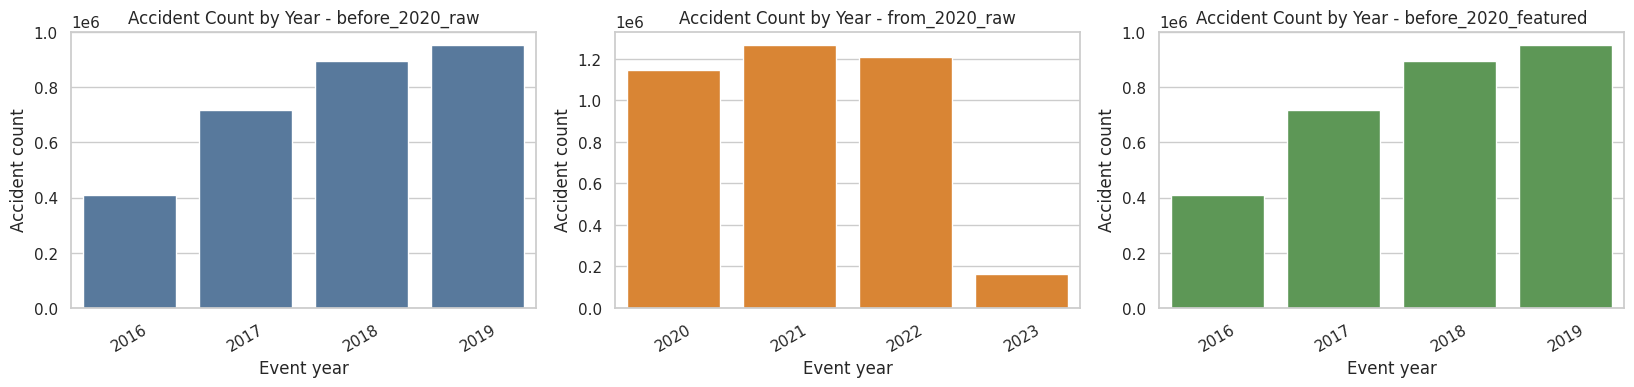

In [5]:
year_counts = (
    eda_df.groupby(["period", "event_year"], observed=True)
    .size()
    .reset_index(name="accident_count")
    .sort_values(["period", "event_year"])
)

display(year_counts)

fig, axes = period_subplots(height=4.2, sharey=False)
for axis, period in zip(axes, PERIOD_ORDER):
    data = year_counts[year_counts["period"] == period]
    sns.barplot(data=data, x="event_year", y="accident_count", ax=axis, color=PERIOD_PALETTE[period])
    axis.set_title(f"Accident Count by Year - {period}")
    axis.set_xlabel("Event year")
    axis.set_ylabel("Accident count")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Target Distribution And Class Imbalance

Severity is the label used as `true_severity`. The before-2020 distribution drives model strategy. The after-2020 distribution is shown for drift awareness only.

count                                              share                                   
period        before_2020_raw from_2020_raw before_2020_featured before_2020_raw from_2020_raw before_2020_featured
true_severity                                                                                                      
1                       969.0       66394.0                969.0        0.000326      0.017532             0.000326
2                   1995128.0     3222878.0            1994654.0        0.670313      0.851054             0.670283
3                    887928.0      411377.0             887867.0        0.298322      0.108631             0.298359
4                     92388.0       86278.0              92347.0        0.031040      0.022783             0.031032

,period,majority_class,majority_count,minority_class,minority_count,majority_to_minority_ratio
0,before_2020_raw,2,1995128,1,969,2058.96
1,from_2020_raw,2,3222878,1,66394,48.54
2,before_2020_featured,2,1994654,1,969,2058.47


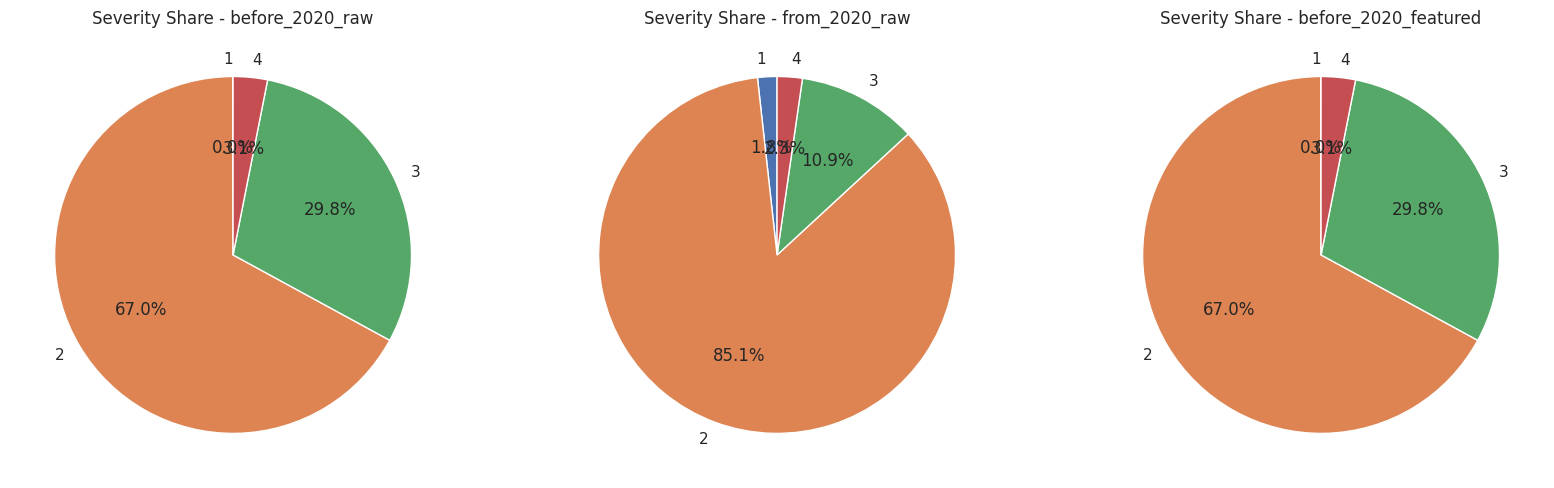

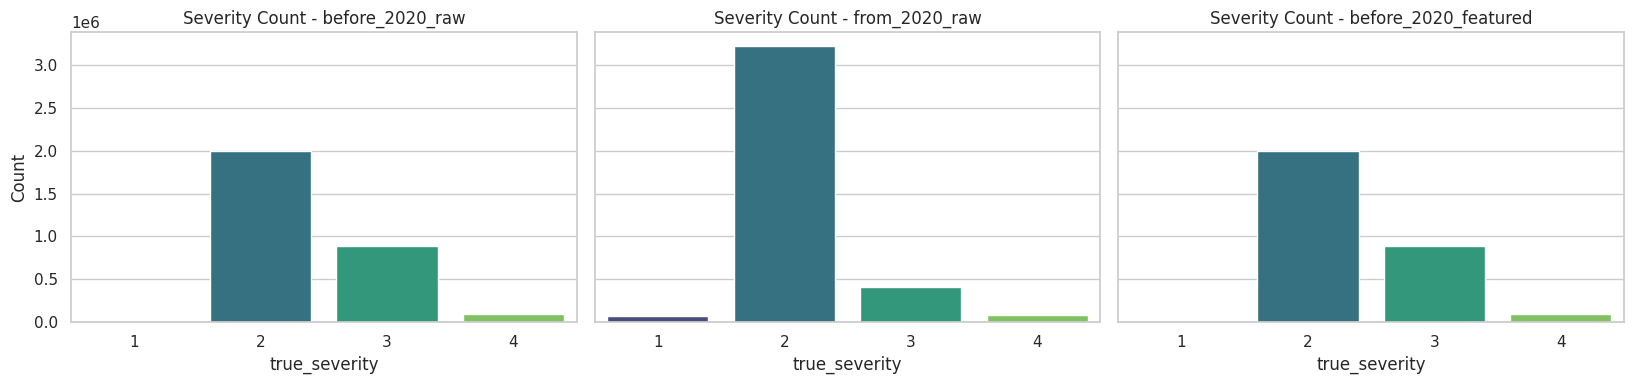

In [6]:
severity_counts = (
    eda_df.groupby(["period", "true_severity"], observed=True)
    .size()
    .reset_index(name="count")
)
severity_counts["share"] = severity_counts["count"] / severity_counts.groupby("period", observed=True)["count"].transform("sum")
severity_pivot = severity_counts.pivot(index="true_severity", columns="period", values=["count", "share"]).fillna(0)

display(severity_pivot)

imbalance_rows = []
for period in PERIOD_ORDER:
    data = eda_df.loc[eda_df["period"] == period]
    counts = data["true_severity"].value_counts().sort_index()
    imbalance_rows.append({
        "period": period,
        "majority_class": int(counts.idxmax()),
        "majority_count": int(counts.max()),
        "minority_class": int(counts.idxmin()),
        "minority_count": int(counts.min()),
        "majority_to_minority_ratio": round(float(counts.max() / counts.min()), 2),
    })
imbalance_table = pd.DataFrame(imbalance_rows)
display(imbalance_table)

fig, axes = period_subplots(height=5)
for axis, period in zip(axes, PERIOD_ORDER):
    data = severity_counts[severity_counts["period"] == period].sort_values("true_severity")
    axis.pie(data["count"], labels=data["true_severity"], autopct="%1.1f%%", startangle=90)
    axis.set_title(f"Severity Share - {period}")
plt.tight_layout()
plt.show()

fig, axes = period_subplots(height=4, sharey=True)
for axis, period in zip(axes, PERIOD_ORDER):
    data = severity_counts[severity_counts["period"] == period]
    sns.barplot(data=data, x="true_severity", y="count", ax=axis, palette="viridis")
    axis.set_title(f"Severity Count - {period}")
    axis.set_xlabel("true_severity")
    axis.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Missing Values And Data Quality

Raw missing-value checks are useful for data engineering. Engineered missing-value checks are the model contract. The model should consume the engineered schema, not a raw concat with mismatched column names.

,feature,missing_count,period,missing_share
7,day_of_week,0,before_2020_raw,0.0
31,day_of_week,0,from_2020_raw,0.0
55,day_of_week,0,before_2020_featured,0.0
0,event_id,0,before_2020_raw,0.0
24,event_id,0,from_2020_raw,0.0
...,...,...,...,...
34,weather_code,0,from_2020_raw,0.0
58,weather_code,0,before_2020_featured,0.0
13,wind_speed_mph,0,before_2020_raw,0.0
37,wind_speed_mph,0,from_2020_raw,0.0


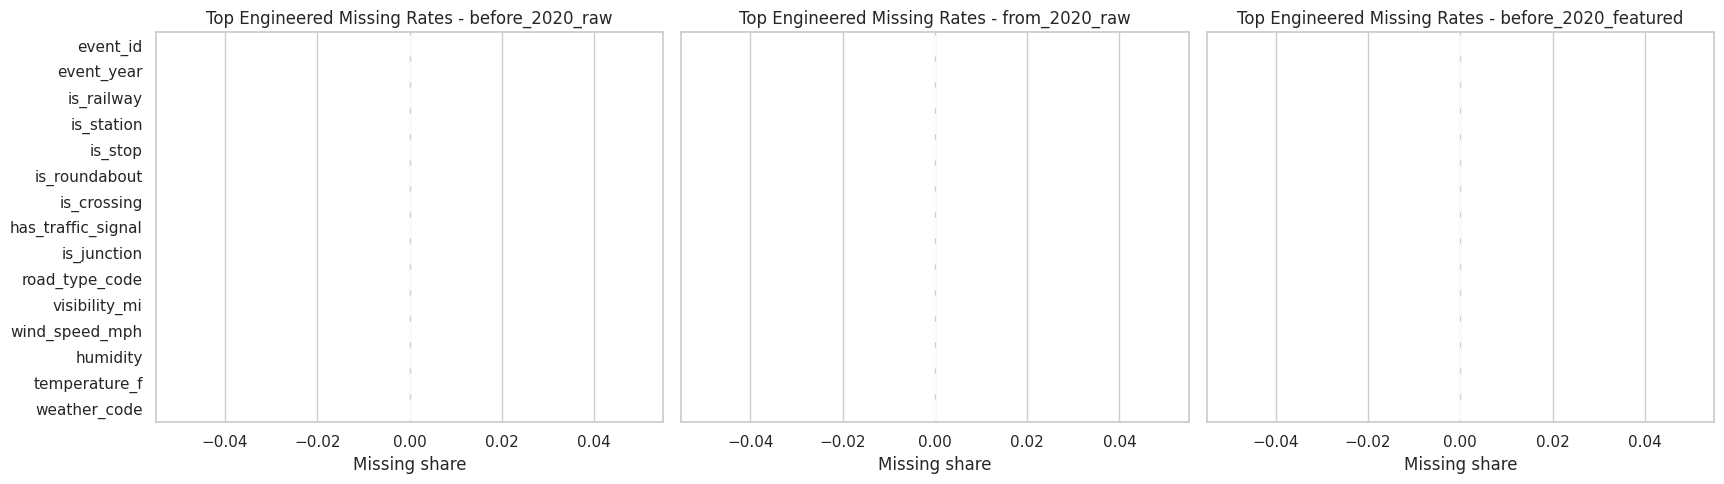

In [7]:
missing_tables = []
for period in PERIOD_ORDER:
    data = eda_df.loc[eda_df["period"] == period]
    missing = data[ENGINEERED_COLUMNS].isna().sum().reset_index()
    missing.columns = ["feature", "missing_count"]
    missing["period"] = period
    missing["missing_share"] = missing["missing_count"] / len(data)
    missing_tables.append(missing)
missing_table = pd.concat(missing_tables, ignore_index=True)

display(missing_table.sort_values(["missing_share", "feature"], ascending=[False, True]))

fig, axes = period_subplots(width=5.8, height=5, sharey=True)
for axis, period in zip(axes, PERIOD_ORDER):
    plot_data = missing_table[missing_table["period"] == period].sort_values("missing_share", ascending=False).head(15)
    sns.barplot(data=plot_data, y="feature", x="missing_share", ax=axis, color=PERIOD_PALETTE[period])
    axis.set_title(f"Top Engineered Missing Rates - {period}")
    axis.set_xlabel("Missing share")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()


## Numeric Feature Distributions And Outliers

Weather variables are clipped in `processing.feature_engineering` to avoid physically impossible values. These histograms verify that training and realtime replay consume bounded values.

temperature_f                                     humidity                                    wind_speed_mph                                  visibility_mi  \
                             count    mean     std   min median    max    count    mean     std  min median    max          count   mean    std  min median    max         count   
period                                                                                                                                                                             
before_2020_raw            2976413  62.113  18.687 -40.0   64.0  130.0  2976413  65.100  22.435  1.0   67.0  100.0        2976413  7.065  5.356  0.0    6.9  100.0       2976413   
from_2020_raw              3786927  60.766  18.875 -40.0   63.0  130.0  3786927  64.448  22.816  1.0   66.0  100.0        3786927  7.110  5.522  0.0    7.0  100.0       3786927   
before_2020_featured       2975837  62.110  18.687 -40.0   64.0  130.0  2975837  65.102  22.435  1.0   67.0  100.0        2975837  7.065  5.356  0.0    6.9  100.0       2975837   

                                                          lat                                             lon                                           
                       mean    std  min median   max    count    mean    std     min  median     max    count    mean     std      min  median     max  
period                                                                                                                                                  
before_2020_raw       9.071  2.259  0.0   10.0  10.0  2976413  36.495  4.919  24.555  35.851  49.002  2976413 -95.424  17.219 -124.624 -90.246 -67.113  
from_2020_raw         9.039  2.350  0.0   10.0  10.0  3786927  36.049  5.128  24.555  35.792  49.001  3786927 -94.307  17.438 -124.548 -86.780 -67.484  
before_2020_featured  9.070  2.259  0.0   10.0  10.0  2975837  36.495  4.919  24.555  35.851  49.002  2975837 -95.419  17.217 -124.624 -90.240 -67.113

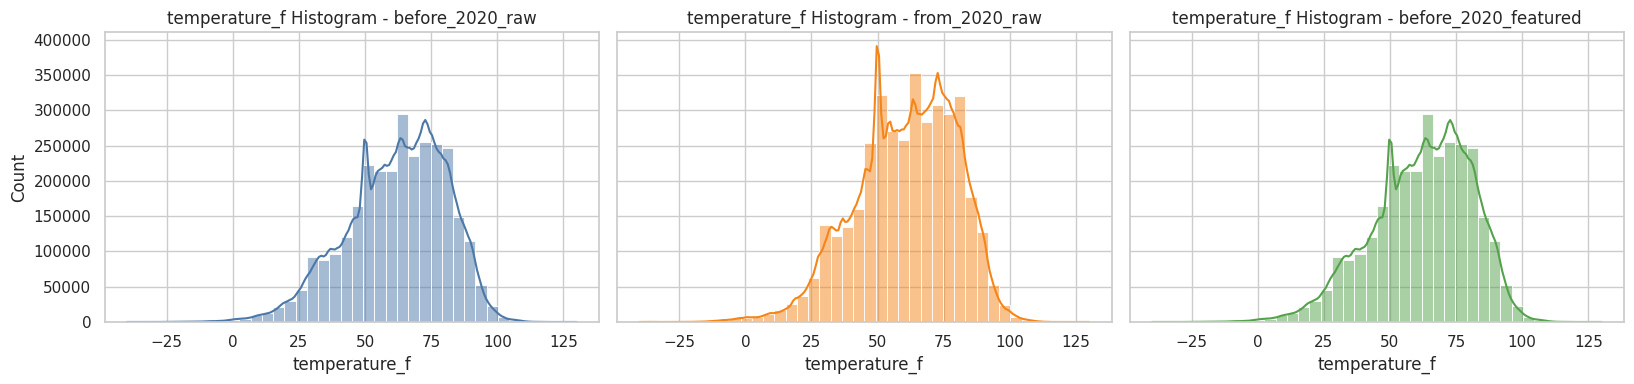

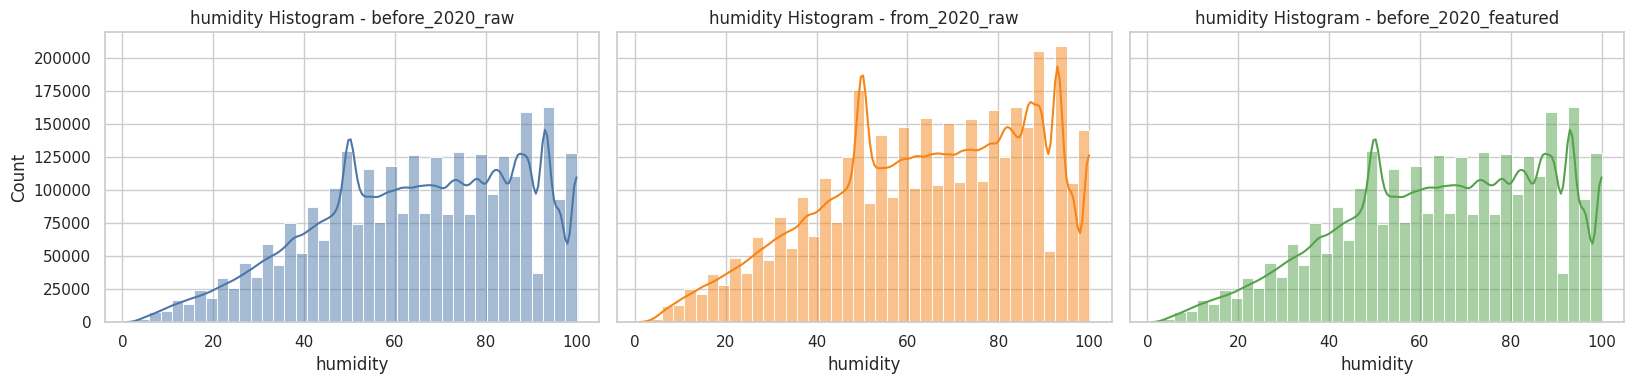

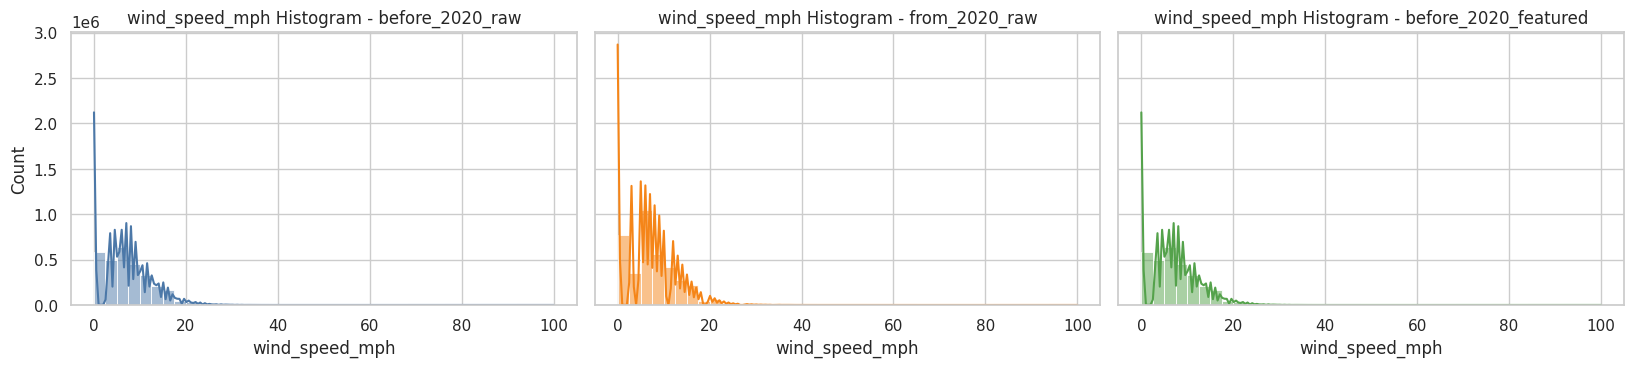

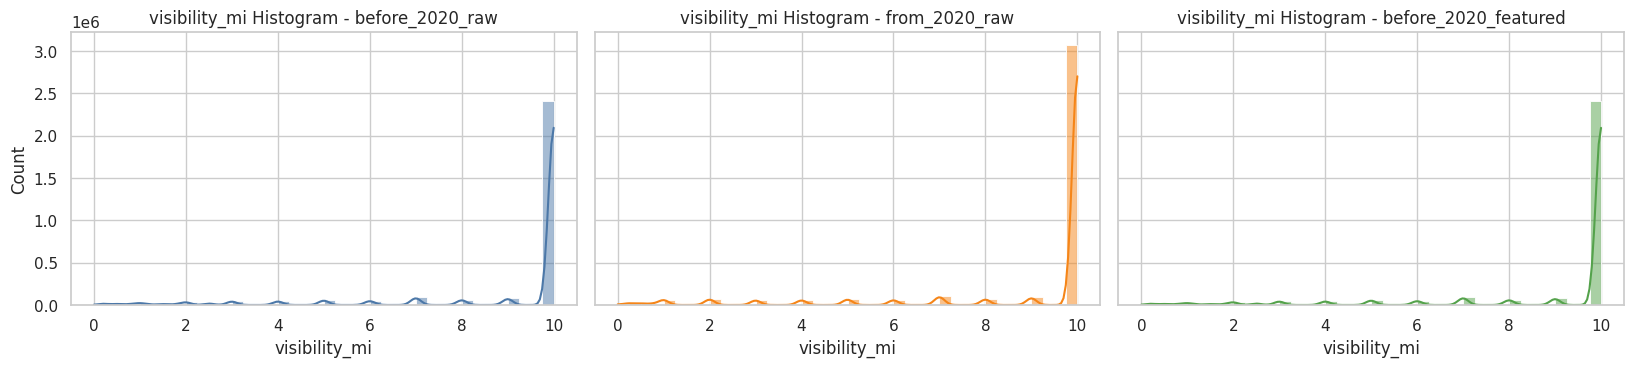

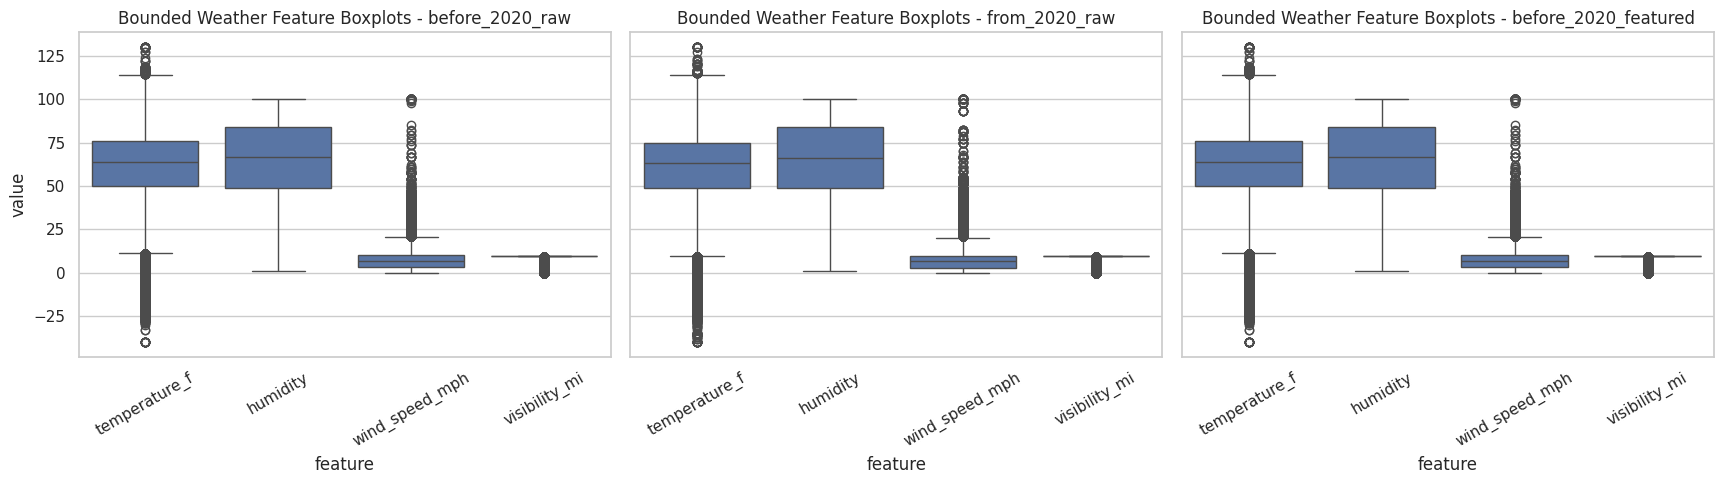

In [8]:
numeric_features = ["temperature_f", "humidity", "wind_speed_mph", "visibility_mi", "lat", "lon"]
summary = (
    eda_df.groupby("period", observed=True)[numeric_features]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(3)
)
display(summary)

for feature in numeric_features[:4]:
    fig, axes = period_subplots(height=4, sharey=True)
    for axis, period in zip(axes, PERIOD_ORDER):
        sns.histplot(eda_df.loc[eda_df["period"] == period, feature], bins=40, kde=True, ax=axis, color=PERIOD_PALETTE[period])
        axis.set_title(f"{feature} Histogram - {period}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

fig, axes = period_subplots(width=5.8, height=5, sharey=True)
for axis, period in zip(axes, PERIOD_ORDER):
    plot_data = eda_df[eda_df["period"] == period][numeric_features[:4]].melt(var_name="feature", value_name="value")
    sns.boxplot(data=plot_data, x="feature", y="value", ax=axis)
    axis.set_title(f"Bounded Weather Feature Boxplots - {period}")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Time-Based Accident Patterns

Rush-hour features should be justified by the data. Counts and average severity are shown by hour for both periods.

,period,hour,accident_count,avg_severity,severe_rate
0,before_2020_raw,0,23184,2.635438,0.488656
1,before_2020_raw,1,17981,2.602414,0.482732
2,before_2020_raw,2,18951,2.620653,0.500607
3,before_2020_raw,3,18609,2.641141,0.512816
4,before_2020_raw,4,53620,2.442465,0.390060
...,...,...,...,...,...
67,before_2020_featured,19,115470,2.387217,0.354153
68,before_2020_featured,20,81772,2.424253,0.381524
69,before_2020_featured,21,57739,2.466219,0.415265
70,before_2020_featured,22,48328,2.491620,0.429130


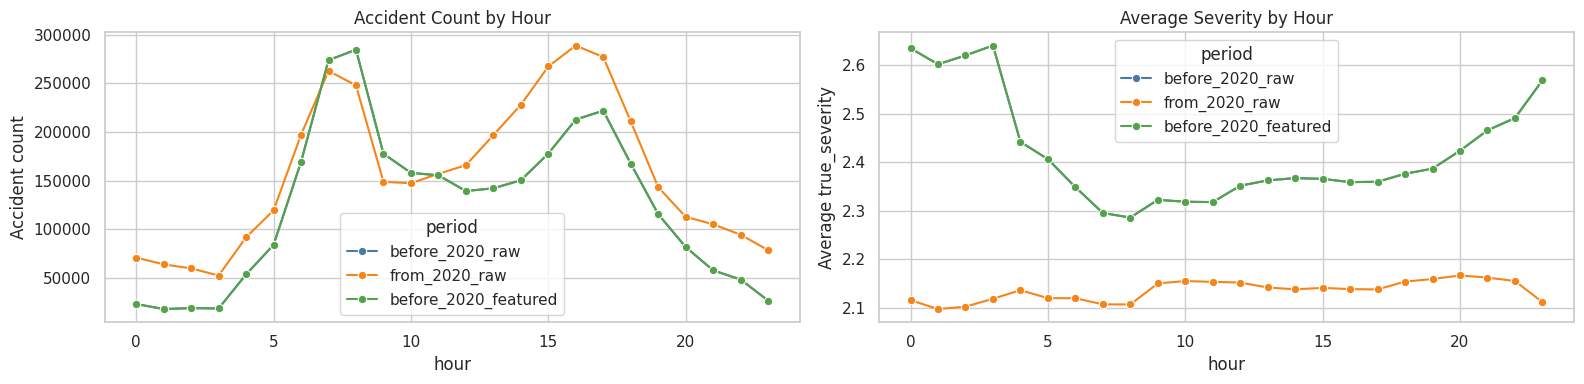

,period,is_rush_hour,is_weekend,accident_count,avg_severity,severe_rate
0,before_2020_raw,0,0,1410389,2.3569,0.3222
1,before_2020_raw,0,1,228021,2.5659,0.5020
2,before_2020_raw,1,0,1243970,2.3110,0.2925
3,before_2020_raw,1,1,94033,2.5578,0.5071
4,from_2020_raw,0,0,1839071,2.1356,0.1268
5,from_2020_raw,0,1,512019,2.1561,0.1336
6,from_2020_raw,1,0,1250022,2.1244,0.1335
7,from_2020_raw,1,1,185815,2.1760,0.1569
8,before_2020_featured,0,0,1410075,2.3569,0.3222
9,before_2020_featured,0,1,227997,2.5659,0.5020


In [9]:
hour_stats = (
    eda_df.groupby(["period", "hour"], observed=True)
    .agg(accident_count=("event_id", "count"), avg_severity=("true_severity", "mean"), severe_rate=("true_severity", lambda s: (s >= 3).mean()))
    .reset_index()
)
display(hour_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
sns.lineplot(data=hour_stats, x="hour", y="accident_count", hue="period", marker="o", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[0])
axes[0].set_title("Accident Count by Hour")
axes[0].set_ylabel("Accident count")
sns.lineplot(data=hour_stats, x="hour", y="avg_severity", hue="period", marker="o", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[1])
axes[1].set_title("Average Severity by Hour")
axes[1].set_ylabel("Average true_severity")
plt.tight_layout()
plt.show()

rush_table = (
    eda_df.groupby(["period", "is_rush_hour", "is_weekend"], observed=True)
    .agg(accident_count=("event_id", "count"), avg_severity=("true_severity", "mean"), severe_rate=("true_severity", lambda s: (s >= 3).mean()))
    .reset_index()
    .round(4)
)
display(rush_table)


## Weather And Road Context

Weather and road context may not have high linear correlation alone, but tree-based H2O models can combine them with location, time, and infrastructure flags.

,period,weather_code,accident_count,avg_severity,severe_rate
0,before_2020_raw,0,1214870,2.3449,0.3132
1,before_2020_raw,1,203897,2.3954,0.3660
2,before_2020_raw,2,49473,2.4681,0.4110
3,before_2020_raw,3,63376,2.3309,0.3069
4,before_2020_raw,4,23682,2.4321,0.4035
5,before_2020_raw,5,1417230,2.3645,0.3351
6,before_2020_raw,6,3885,2.2780,0.2517
7,from_2020_raw,0,1865262,2.1211,0.1175
8,from_2020_raw,1,254489,2.1824,0.1709
9,from_2020_raw,2,85960,2.1583,0.1307


,period,road_type_code,accident_count,avg_severity,severe_rate
0,before_2020_raw,0,485570,2.3169,0.2879
1,before_2020_raw,1,1057356,2.5716,0.5344
2,before_2020_raw,2,124021,2.4386,0.3727
3,before_2020_raw,3,309977,2.1907,0.1686
4,before_2020_raw,4,249983,2.2110,0.1923
5,before_2020_raw,5,145557,2.2294,0.2129
6,before_2020_raw,6,126219,2.1231,0.1114
7,before_2020_raw,7,477730,2.2056,0.1755
8,from_2020_raw,0,691262,2.1286,0.1212
9,from_2020_raw,1,1422375,2.2175,0.2018


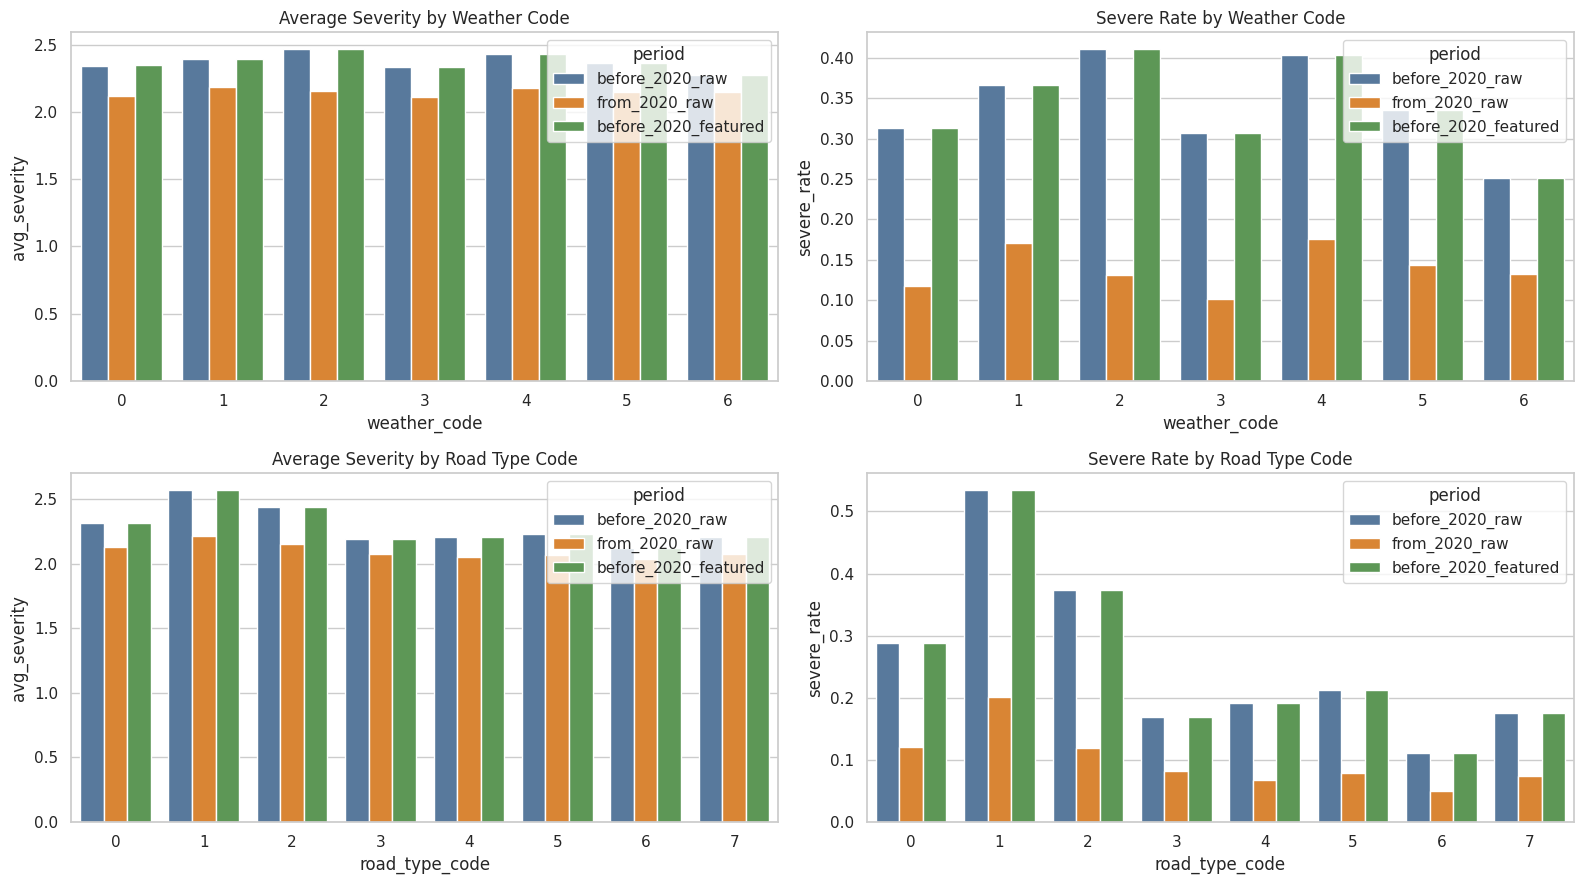

In [10]:
weather_stats = (
    eda_df.groupby(["period", "weather_code"], observed=True)
    .agg(accident_count=("event_id", "count"), avg_severity=("true_severity", "mean"), severe_rate=("true_severity", lambda s: (s >= 3).mean()))
    .reset_index()
    .round(4)
)
road_stats = (
    eda_df.groupby(["period", "road_type_code"], observed=True)
    .agg(accident_count=("event_id", "count"), avg_severity=("true_severity", "mean"), severe_rate=("true_severity", lambda s: (s >= 3).mean()))
    .reset_index()
    .round(4)
)

display(weather_stats)
display(road_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
sns.barplot(data=weather_stats, x="weather_code", y="avg_severity", hue="period", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[0, 0])
axes[0, 0].set_title("Average Severity by Weather Code")
sns.barplot(data=weather_stats, x="weather_code", y="severe_rate", hue="period", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[0, 1])
axes[0, 1].set_title("Severe Rate by Weather Code")
sns.barplot(data=road_stats, x="road_type_code", y="avg_severity", hue="period", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[1, 0])
axes[1, 0].set_title("Average Severity by Road Type Code")
sns.barplot(data=road_stats, x="road_type_code", y="severe_rate", hue="period", hue_order=PERIOD_ORDER, palette=PERIOD_PALETTE, ax=axes[1, 1])
axes[1, 1].set_title("Severe Rate by Road Type Code")
plt.tight_layout()
plt.show()


,period,feature,value,accident_count,avg_severity,severe_rate
0,before_2020_raw,is_junction,0,2727026,2.3492,0.3196
1,before_2020_raw,is_junction,1,249387,2.4791,0.4360
2,before_2020_raw,has_traffic_signal,0,2386869,2.4161,0.3816
3,before_2020_raw,has_traffic_signal,1,589544,2.1333,0.1180
4,before_2020_raw,is_crossing,0,2588656,2.3967,0.3639
5,before_2020_raw,is_crossing,1,387757,2.1158,0.0990
6,before_2020_raw,is_roundabout,0,2976309,2.3601,0.3294
7,before_2020_raw,is_roundabout,1,104,2.1346,0.0865
8,before_2020_raw,is_stop,0,2891379,2.3673,0.3365
9,before_2020_raw,is_stop,1,85034,2.1148,0.0871


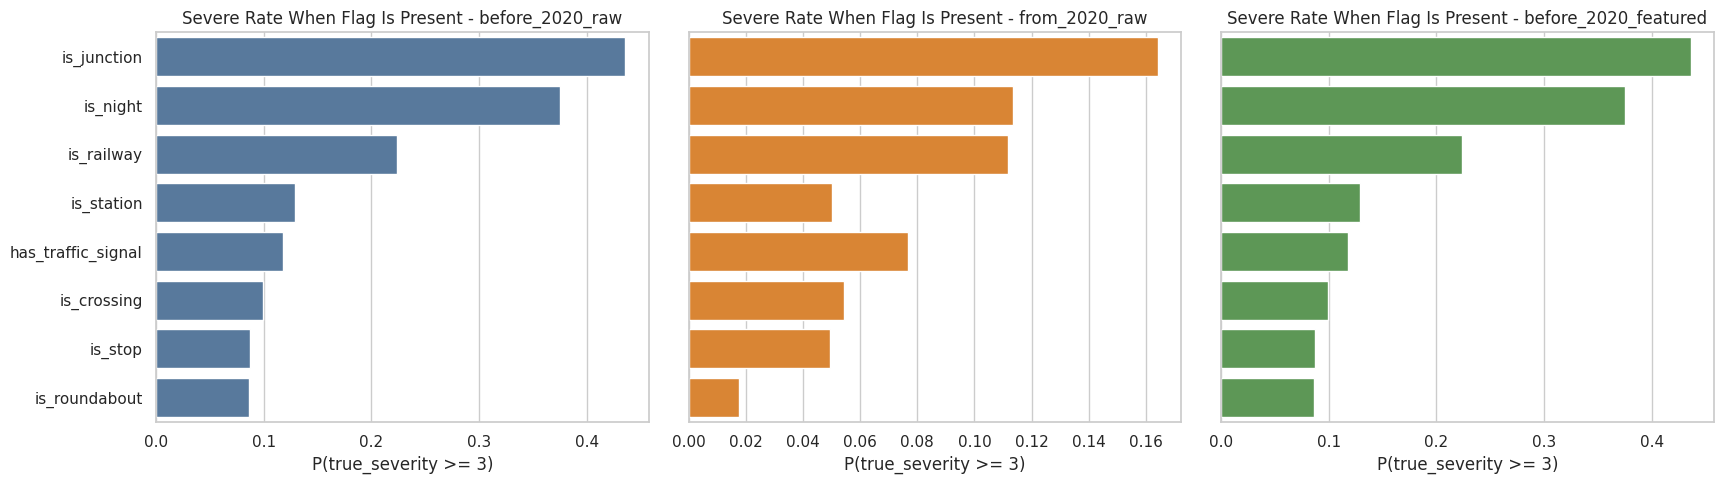

In [11]:
road_flags = ["is_junction", "has_traffic_signal", "is_crossing", "is_roundabout", "is_stop", "is_station", "is_railway", "is_night"]
flag_rows = []
for period in PERIOD_ORDER:
    data = eda_df.loc[eda_df["period"] == period]
    for flag in road_flags:
        grouped = data.groupby(flag).agg(
            accident_count=("event_id", "count"),
            avg_severity=("true_severity", "mean"),
            severe_rate=("true_severity", lambda s: (s >= 3).mean()),
        ).reset_index()
        for _, row in grouped.iterrows():
            flag_rows.append({"period": period, "feature": flag, "value": int(row[flag]), "accident_count": int(row["accident_count"]), "avg_severity": row["avg_severity"], "severe_rate": row["severe_rate"]})
flag_table = pd.DataFrame(flag_rows).round(4)
display(flag_table)

fig, axes = period_subplots(width=5.8, height=5, sharey=True)
for axis, period in zip(axes, PERIOD_ORDER):
    plot_data = flag_table[(flag_table["period"] == period) & (flag_table["value"] == 1)].sort_values("severe_rate", ascending=False)
    sns.barplot(data=plot_data, y="feature", x="severe_rate", ax=axis, color=PERIOD_PALETTE[period])
    axis.set_title(f"Severe Rate When Flag Is Present - {period}")
    axis.set_xlabel("P(true_severity >= 3)")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()


## Correlation Analysis

Correlation is calculated on engineered numeric features. The heatmap is visual, and the table ranks features by absolute correlation with `true_severity` for report writing.

Top correlations for before_2020_raw


,feature,correlation_with_true_severity
0,road_type_code,-0.215092
1,has_traffic_signal,-0.208167
2,is_crossing,-0.174584
3,is_weekend,0.130893
4,is_stop,-0.077691
5,is_night,0.068944
6,is_junction,0.066471
7,is_station,-0.064320
8,lon,0.055233
9,is_rush_hour,-0.052948


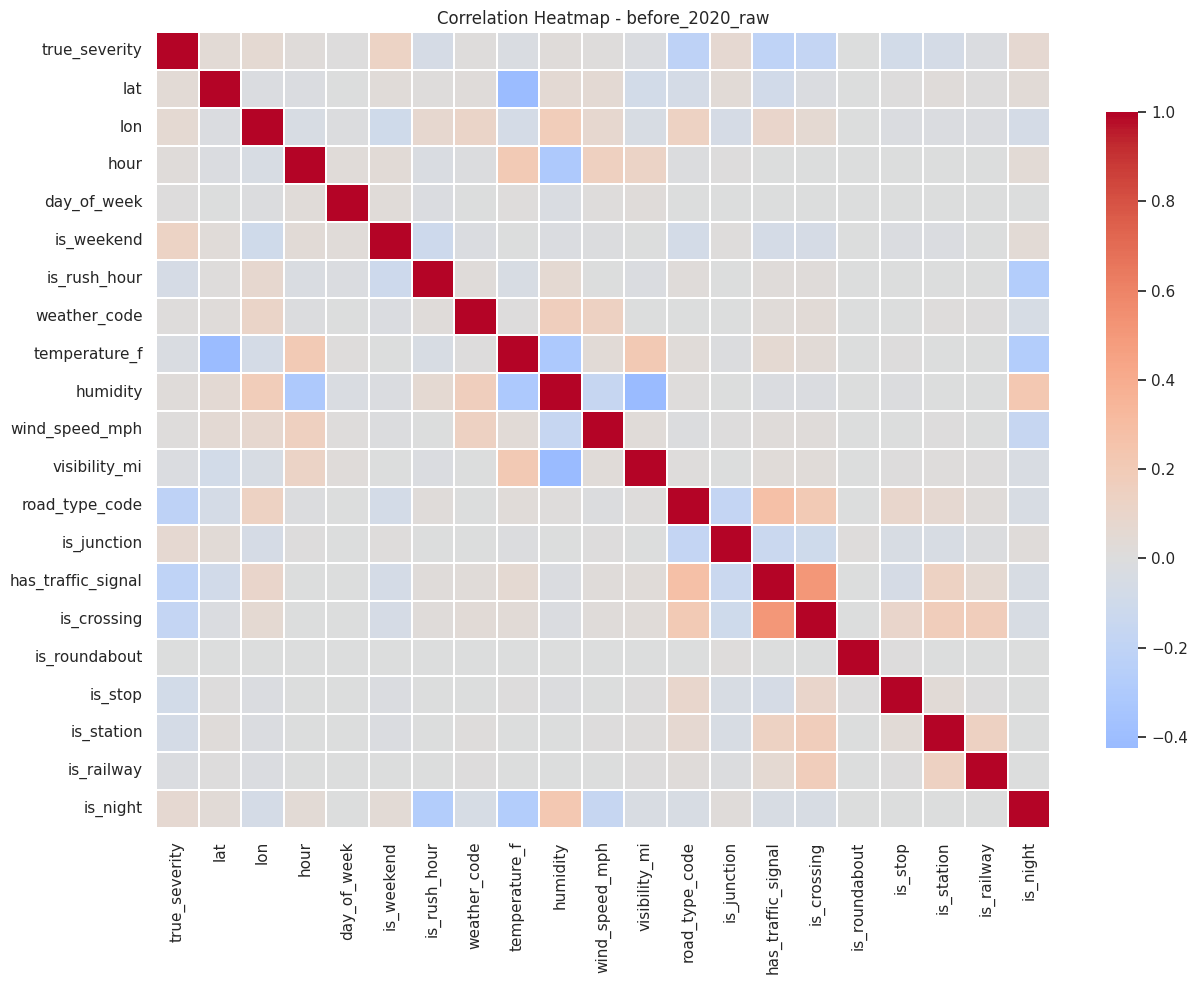

Top correlations for from_2020_raw


,feature,correlation_with_true_severity
0,road_type_code,-0.109170
1,is_crossing,-0.088624
2,has_traffic_signal,-0.082673
3,lon,0.071968
4,lat,0.071560
5,is_station,-0.037423
6,is_stop,-0.033293
7,is_junction,0.027635
8,hour,0.027439
9,is_weekend,0.026359


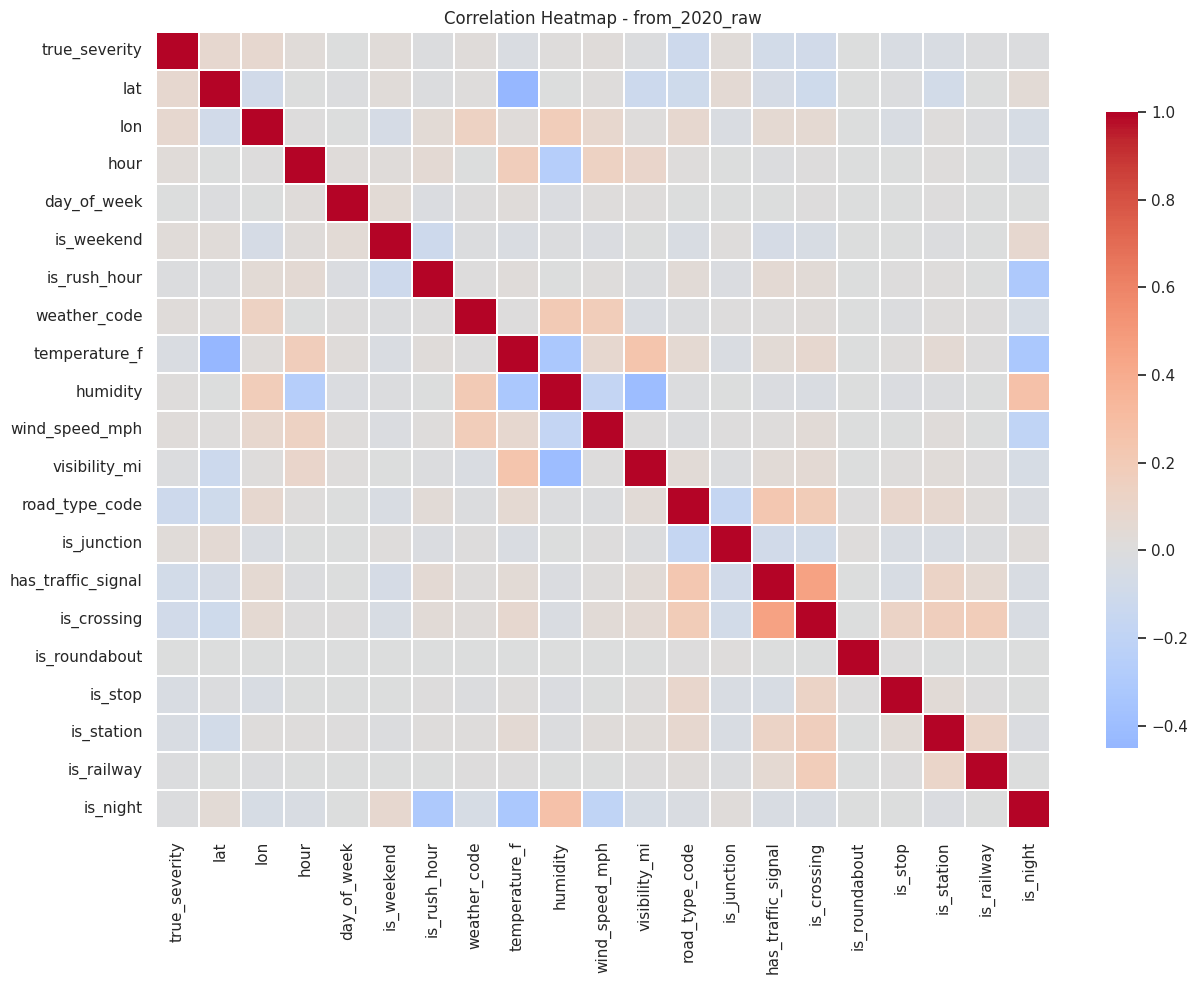

Top correlations for before_2020_featured


,feature,correlation_with_true_severity
0,road_type_code,-0.215173
1,has_traffic_signal,-0.208224
2,is_crossing,-0.174636
3,is_weekend,0.130881
4,is_stop,-0.077717
5,is_night,0.068917
6,is_junction,0.066552
7,is_station,-0.064356
8,lon,0.055200
9,is_rush_hour,-0.052938


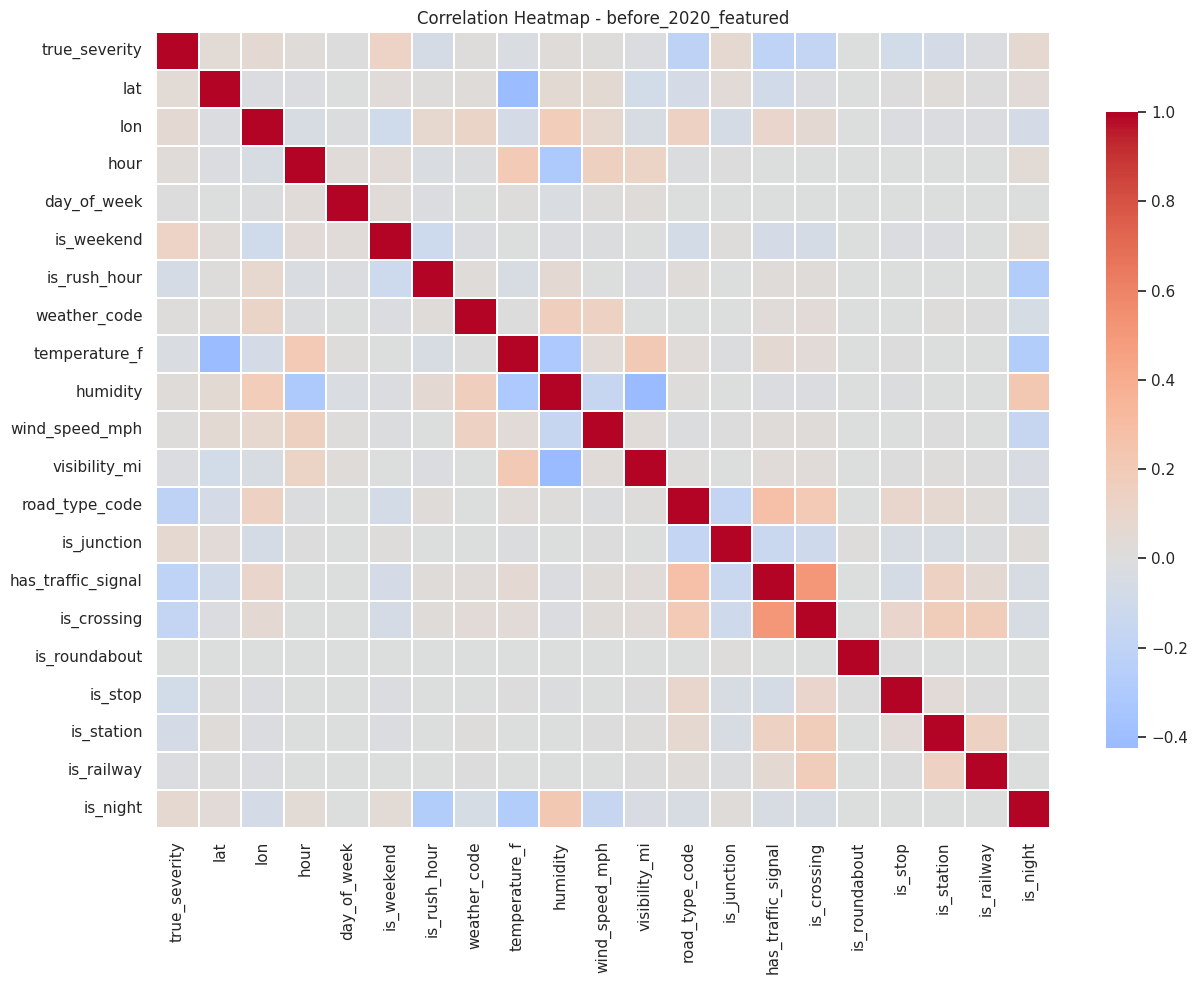

In [12]:
corr_features = [
    "true_severity", "lat", "lon", "hour", "day_of_week", "is_weekend", "is_rush_hour",
    "weather_code", "temperature_f", "humidity", "wind_speed_mph", "visibility_mi",
    "road_type_code", "is_junction", "has_traffic_signal", "is_crossing",
    "is_roundabout", "is_stop", "is_station", "is_railway", "is_night",
]

for period in PERIOD_ORDER:
    corr = eda_df.loc[eda_df["period"] == period, corr_features].corr(numeric_only=True)
    severity_corr = (
        corr["true_severity"].drop("true_severity").sort_values(key=lambda s: s.abs(), ascending=False).reset_index()
    )
    severity_corr.columns = ["feature", "correlation_with_true_severity"]
    print(f"Top correlations for {period}")
    display(severity_corr.head(15))

    plt.figure(figsize=(13, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2, cbar_kws={"shrink": 0.8})
    plt.title(f"Correlation Heatmap - {period}")
    plt.tight_layout()
    plt.show()


## Spatial Sanity Check

The model consumes latitude and longitude. These plots confirm that sampled records remain in the expected US coordinate range after feature engineering.

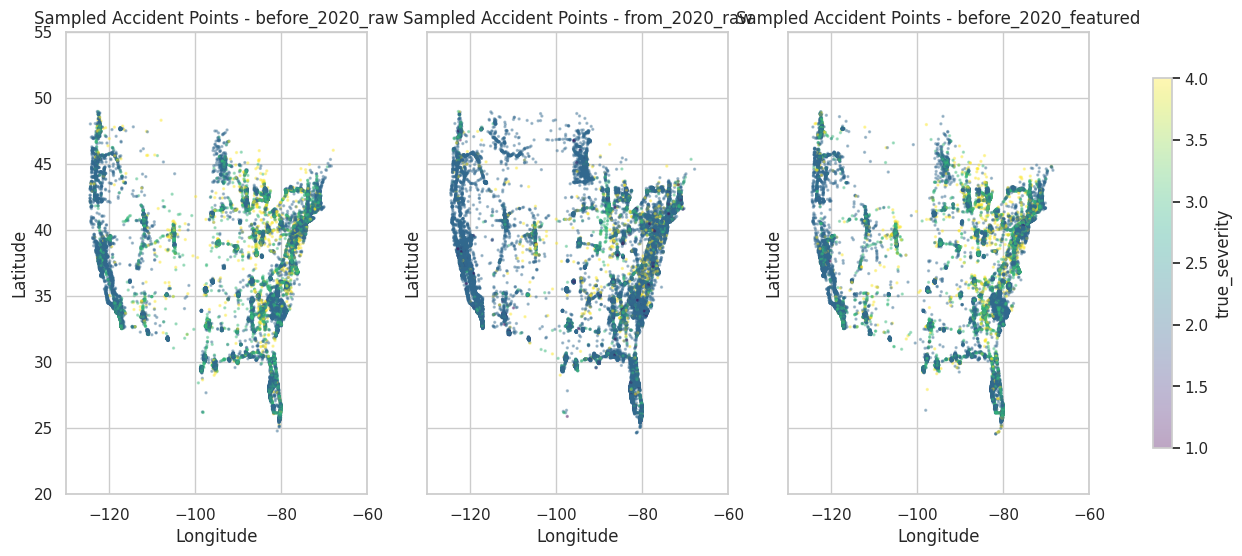

In [13]:
MAX_SCATTER_ROWS_PER_PERIOD = 50_000
fig, axes = period_subplots(width=5.5, height=6, sharex=True, sharey=True)
for axis, period in zip(axes, PERIOD_ORDER):
    period_mask = eda_df["period"] == period
    plot_data = eda_df.loc[period_mask].sample(min(MAX_SCATTER_ROWS_PER_PERIOD, int(period_mask.sum())), random_state=RANDOM_SEED)
    scatter = axis.scatter(plot_data["lon"], plot_data["lat"], c=plot_data["true_severity"], s=2, alpha=0.35, cmap="viridis")
    axis.set_title(f"Sampled Accident Points - {period}")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.set_xlim(-130, -60)
    axis.set_ylim(20, 55)
fig.colorbar(scatter, ax=axes, label="true_severity", shrink=0.8)
plt.show()


## Feature And Modeling Decisions From Before-2020 Only

Use the from-2020 raw split for drift visibility and replay testing, not for initial model selection. Compare `before_2020_raw` with `before_2020_featured` to confirm the feature-engineering contract preserves row scope and produces stable model inputs. Based on the before-2020 analysis:

- Keep the unified engineered schema from the production feature contract.
- Use H2O tree-based AutoML models instead of a linear-only model because correlations with severity are weak and interactions matter.
- Enable `balance_classes=True` and explicit bounded `class_sampling_factors` because severity 4 is rare.
- Report macro F1, weighted F1, per-class recall, and confusion matrix instead of accuracy alone.
- Keep clipped weather variables because they reduce outlier influence without removing valid accident rows.
